In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import fitsio as fio

from pathlib import Path

hsc = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits')

buzzard_index = 0
root_buzzard = Path(
    f'/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0/buzzard-{buzzard_index}/addgalspostprocess'
    )
desi_tgts = root_buzzard / 'desi_targets_v1.2' 
truth = root_buzzard / 'truth' 
chinchilla_pix = 0

(array([1.000e+00, 0.000e+00, 0.000e+00, ..., 2.439e+03, 2.550e+03,
        2.449e+03]),
 array([18.37169266, 18.37240601, 18.37311745, ..., 25.4985733 ,
        25.49928474, 25.49999809]),
 <BarContainer object of 10000 artists>)

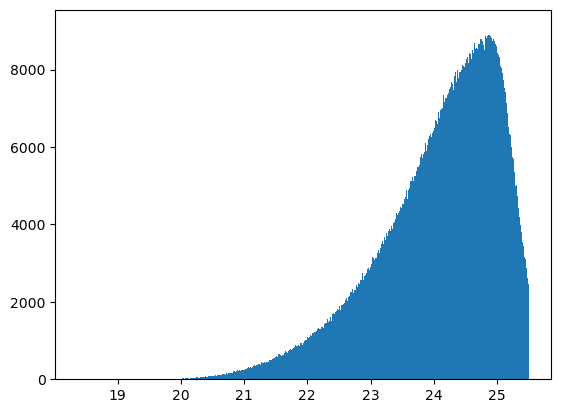

In [7]:
plt.hist(hsc[1]['aperture_mag'].read(), bins=10000)

In [ ]:
os.listdir(root_buzzard / 'surveymags')
tbl = fio.FITS(root_buzzard / 'desi_targets' / 'bgs_all.fits')

In [ ]:
tbl = fio.FITS(root_buzzard / 'truth' / f'Chinchilla-{chinchilla_pix}_cam_rs_scat_shift_lensed.36.fits')
mags = fio.FITS(root_buzzard / 'surveymags' / 'surveymags-aux.36.fits')
print(tbl[1].get_colnames())
print(mags[1].get_colnames())

['PX', 'PY', 'PZ', 'VX', 'VY', 'VZ', 'Z_COS', 'Z', 'MAG_R', 'DIST8', 'M200', 'R200', 'RHALO', 'HALOID', 'CENTRAL', 'BAD_ASSIGN', 'SIGMA5', 'PSIGMA5', 'SEDID', 'MAG_R_EVOL', 'TMAG', 'AMAG', 'TSIZE', 'TE', 'EPSILON_IA', 'COMOVING_SIZE', 'ID', 'TRA', 'TDEC', 'EPSILON', 'SIZE', 'KAPPA', 'MU', 'W', 'GAMMA1', 'GAMMA2', 'DEC', 'RA', 'LMAG', 'OMAG', 'OMAGERR', 'FLUX', 'IVAR']
['TMAG', 'AMAG', 'LMAG', 'OMAG', 'OMAGERR', 'FLUX', 'IVAR', 'Z']


In [70]:
lens_ap_mag = mags[1]['LMAG'].read()
filters = np.loadtxt('filters.txt', dtype=str)

In [71]:
unlensed_ap_mag = mags[1]['TMAG'].read()

Text(0.5, 1.0, 'Noiseless, apparent Magnitudes in different filters')

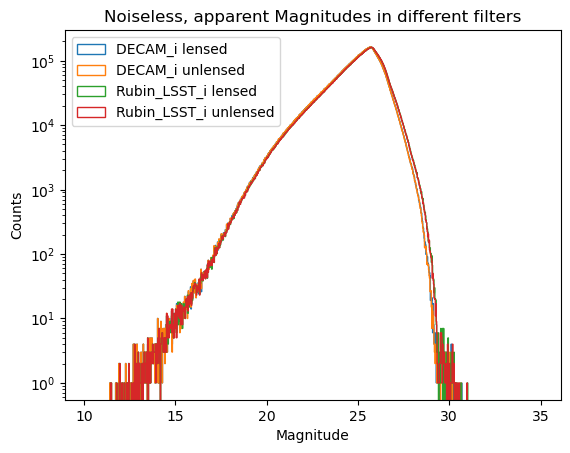

In [73]:
bounds = (np.min(lens_ap_mag), np.max(lens_ap_mag))
for i in range(len(filters)):
    if '_i' in str(filters[i]):
        filt = str(filters[i])
        plt.hist(lens_ap_mag[:, i], bins=1000, range=bounds, histtype='step', label=filt + ' lensed')
        plt.hist(unlensed_ap_mag[:, i], bins=1000, range=bounds, histtype='step', label=filt + ' unlensed')
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Counts')
plt.legend()
plt.title('Noiseless, apparent Magnitudes in different filters')

In [ ]:
plt.hist(mags[1]['mag'], bins=10000)

In [17]:
tbl[1].get_colnames()

['mag_g',
 'mag_r',
 'mag_z',
 'mag_w1',
 'mag_w2',
 'fibermag_g',
 'fibermag_r',
 'fibermag_z',
 'z',
 'z_cos',
 'ra',
 'dec',
 'size',
 'z_phot_median',
 'isbgs_bright',
 'isbgs_faint',
 'islrg',
 'iselg']

In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4])
arr2 = np.array([0.1, 0.2, 0.3, 0.4])
r_trans = (arr[:, None] + arr2)
r_pper = (arr[:, None] / arr2)
mask = (r_trans > 2) & (r_pper < 20)
print(mask)
print(r_pper)
print(r_trans)
print(np.nonzero(mask))
for i,j in zip(*np.nonzero(mask)):
    print(i,j,r_pper[i][j])
print("="*80)
for i, a in enumerate(arr):
    for j,b in enumerate(arr2):
        rp = a/b
        rt = a+b
        if rt > 2 and rp < 20:
            print(i,j,rp)

[[False False False False]
 [False  True  True  True]
 [False  True  True  True]
 [False False  True  True]]
[[10.          5.          3.33333333  2.5       ]
 [20.         10.          6.66666667  5.        ]
 [30.         15.         10.          7.5       ]
 [40.         20.         13.33333333 10.        ]]
[[1.1 1.2 1.3 1.4]
 [2.1 2.2 2.3 2.4]
 [3.1 3.2 3.3 3.4]
 [4.1 4.2 4.3 4.4]]
(array([1, 1, 1, 2, 2, 2, 3, 3]), array([1, 2, 3, 1, 2, 3, 2, 3]))
1 1 10.0
1 2 6.666666666666667
1 3 5.0
2 1 15.0
2 2 10.0
2 3 7.5
3 2 13.333333333333334
3 3 10.0
1 1 10.0
1 2 6.666666666666667
1 3 5.0
2 1 15.0
2 2 10.0
2 3 7.5
3 2 13.333333333333334
3 3 10.0


In [23]:
np.nonzero(mask)

(array([0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3]),
 array([2, 3, 1, 2, 3, 0, 1, 2, 3, 1, 2, 3]))

In [24]:
from astropy.cosmology import Planck18
import numpy as np

# 2D array of redshift values
redshifts = np.array([[0.1, 0.2, 0.3],
                      [0.4, 0.5, 0.6]])

# Calculate comoving distances for the 2D array of redshifts
distances = Planck18.comoving_distance(redshifts)

print(distances)


[[ 432.56569774  843.57789943 1232.70666727]
 [1600.12875416 1946.41663479 2272.42630039]] Mpc


In [ ]:
def batched(data, iterator, batch_size):
    '''
    Yields successive batches of size `batch_size` from the iterator.
    '''
    batch = [[], []]
    for item in iterator:
        i, j = item
        batch[0].append(data[i])
        batch[1].append(data[j])
        if len(batch[0]) == batch_size:
            yield batch
            batch = [[], []]
    if batch:
        yield batch

In [26]:
import pandas as pd
import itertools
df = pd.DataFrame({
    'a': [1, 2, 3, 4, 5],
    'b': [6, 7, 8, 9, 10]
})
gen = batched(df, ((i, j) for i, j in itertools.combinations(range(len(df)), 2)), 2)

In [27]:
gen = df.iterrows()

In [21]:
gen = ((i, j) for i, j in itertools.combinations(range(len(df)), 2))
next(gen)

(0, 1)

In [24]:
for batch in gen:
    print(batch)
    # Do something with the batch
    # For example, you can convert it to a DataFrame
    batch_df = pd.DataFrame({'a': batch[0], 'b': batch[1]})
    print(batch_df)

(0, 1)


KeyError: 0

In [3]:
obj1 = ([0.1, 0.2, 100], [0.3, 0.4, 105])
obj2 = ([0.5, 0.6, -30], [0.7, 0.8, 210])
import numpy as np

def fastsep(obj1, obj2):
    # https://github.com/dkirkby/MachineLearningStatistics/blob/master/notebooks/TensorComputing.ipynb
    ra1, dec1 = np.deg2rad(obj1)
    ra2, dec2 = np.deg2rad(obj2)
    
    return 2 * np.arcsin(np.sqrt(
        np.sin(0.5 * (dec2 - dec1)) ** 2 +
        np.cos(dec1) * np.cos(dec2) * np.sin(0.5 * (ra2 - ra1)) ** 2))

In [4]:
fastsep(obj1, obj2)

array([0.00987288, 0.00987279, 2.24854366])

In [6]:
df = pd.DataFrame({
    'a': [1, 2, 3, 4, 5],
    'b': [6, 7, 8, 9, 10]
})
df.iloc[0]

a    1
b    6
Name: 0, dtype: int64

In [7]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

def sph_to_cart(ra, dec):
    """
    Convert spherical coordinates (ra, dec) to Cartesian coordinates (x, y, z).
    """
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)
    
    x = np.cos(dec_rad) * np.cos(ra_rad)
    y = np.cos(dec_rad) * np.sin(ra_rad)
    z = np.sin(dec_rad)
    
    return x, y, z

xyz = sph_to_cart(df['a'], df['b'])
tree = cKDTree(xyz)
# Example query point
pairs = tree.query_ball_tree(tree, 0.1)

In [26]:
import fitsio as fio
import os 
from pathlib import Path
delta_root = Path('/global/cfs/cdirs/desi/users/abault/spenderq/deltas_lya/Delta/')
delta_files = list(delta_root.glob("*fits"))
print(len(delta_files))

393


In [46]:
ns = 0
tgts = []
ra = []
dec = []
for i, file in enumerate(delta_files):
    if i % 50 == 0:
        print(f'Progress : {(i+1)/len(delta_files)*100:.2f}%')
    tbl = fio.FITS(file)
    newtgts = tbl[2]['TARGETID'].read()
    newra = tbl[2]['RA'].read()
    newdec = tbl[2]['DEC'].read()
    if len(newtgts) == 0:
        continue
    ra.extend(newra)
    dec.extend(newdec)
    tgts.extend(newtgts)
    ns += len(newtgts)

Progress : 0.25%
Progress : 12.98%
Progress : 25.70%
Progress : 38.42%
Progress : 51.15%
Progress : 63.87%
Progress : 76.59%
Progress : 89.31%


In [48]:
print(max(np.rad2deg(ra)), max(np.rad2deg(dec)))
print(min(ra), min(dec))

359.99957275390625 79.08169555664064
1.504516053259588e-05 -0.33927101022566347


In [29]:
print(f'Number of targets : {ns}')

Number of targets : 401816


In [2]:
cat = Path('/global/cfs/cdirs/desi/users/abault/spenderq/zcat_hpx_8_batch.fits')
catbtl = fio.FITS(cat)
cattgts= catbtl[1]['ra'].read()

In [3]:
cattgts

array([ 46.048996,  44.989815,  45.728325, ..., 295.71524 , 294.39853 ,
       295.63113 ], dtype=float32)

In [4]:
arr = np.array([1, 2, 3, 4])
print(arr[:0])

[]


In [36]:
print(tgts[:10])
print(cattgts[:10])

[90343822, 90344025, 90344461, 90344648, 90344903, 90344907, 90344912, 90344917, 90344918, 90345121]
[58959 59236 59240 60107 60115 60396 60409 60683 60693 60697]


In [40]:
import numpy as np
print(len(tgts))
print(len(cattgts))
np.isin(tgts, cattgts)
np.isin(cattgts, tgts)
print(np.isin(cattgts, tgts).sum())
print(np.isin(tgts, cattgts).sum())

401816
634536
401816
401816
